In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cấu hình biểu đồ
sns.set_theme(style="whitegrid")

# Load dữ liệu
df = pd.read_csv('../data/raw/ai4i2020.csv')
print(f"Kích thước dữ liệu: {df.shape}")
display(df.head())

Kích thước dữ liệu: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
print("Số lượng giá trị thiếu (Missing values):")
print(df.isnull().sum())

print(f"\nSố lượng dòng trùng lặp (Duplicates): {df.duplicated().sum()}")

Số lượng giá trị thiếu (Missing values):
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Số lượng dòng trùng lặp (Duplicates): 0


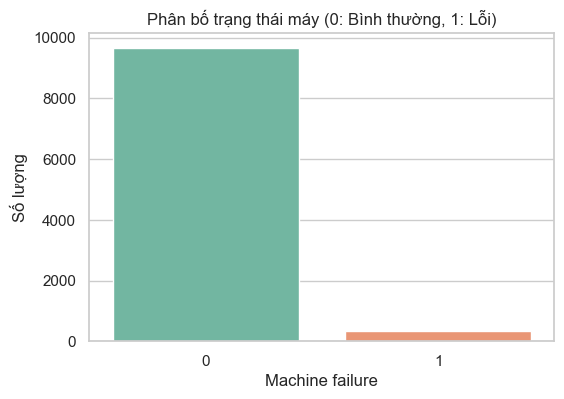

Tỷ lệ máy lỗi chỉ chiếm: 3.39% -> Dữ liệu cực kỳ mất cân bằng!


In [8]:
# Đề bài yêu cầu phải nêu ra vấn đề "Imbalance" (mất cân bằng)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Machine failure', palette='Set2')
plt.title('Phân bố trạng thái máy (0: Bình thường, 1: Lỗi)')
plt.ylabel('Số lượng')
plt.show()

# Tính tỷ lệ
loi = df['Machine failure'].sum()
tong = len(df)
print(f"Tỷ lệ máy lỗi chỉ chiếm: {(loi/tong)*100:.2f}% -> Dữ liệu cực kỳ mất cân bằng!")

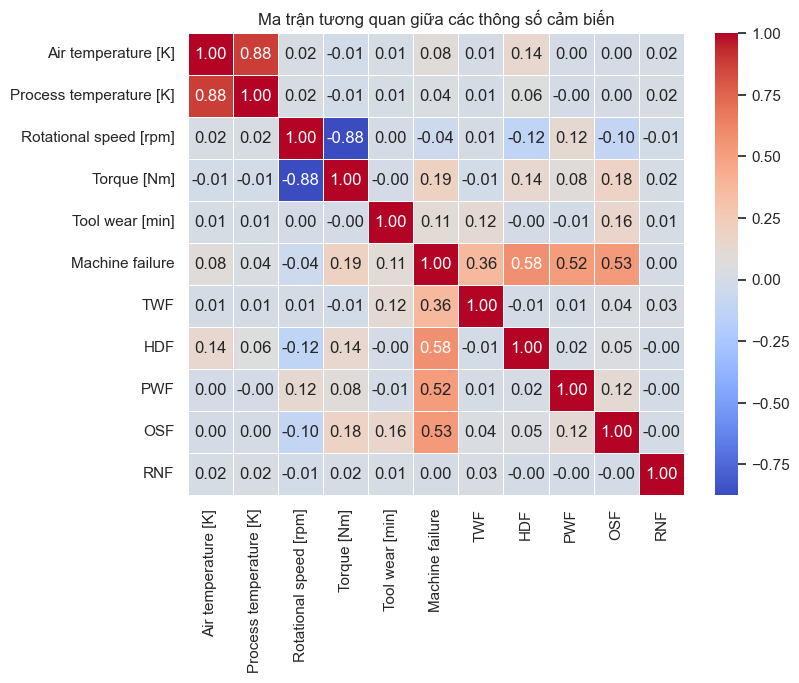

In [9]:
plt.figure(figsize=(8, 6))
# Xóa các cột định danh trước, sau đó lọc lấy các cột kiểu số
num_cols = df.drop(columns=['UDI', 'Product ID']).select_dtypes(include=['float64', 'int64'])
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan giữa các thông số cảm biến')
plt.show()

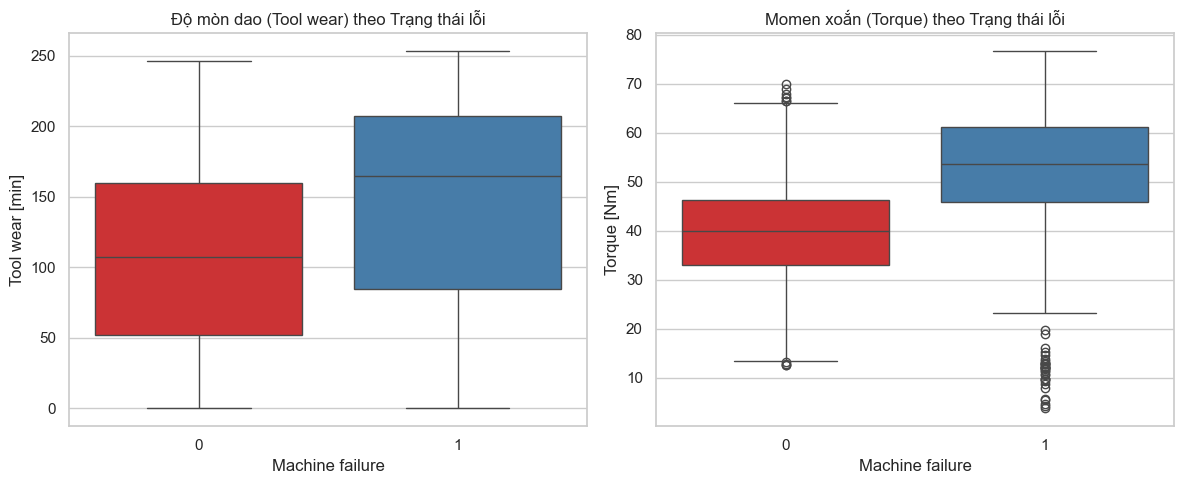

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ mòn dao
sns.boxplot(ax=axes[0], data=df, x='Machine failure', y='Tool wear [min]', palette='Set1')
axes[0].set_title('Độ mòn dao (Tool wear) theo Trạng thái lỗi')

# Biểu đồ momen xoắn
sns.boxplot(ax=axes[1], data=df, x='Machine failure', y='Torque [Nm]', palette='Set1')
axes[1].set_title('Momen xoắn (Torque) theo Trạng thái lỗi')

plt.tight_layout()
plt.show()